# Week 3 – TensorFlow, GenAI & Prompt Engineering
## Abd Ur Rahman

AI/ML Internship – Skill Set Go EduTech

This notebook contains all four Week 3 tasks:

- 3.1 TensorFlow/Keras Model
- 3.2 Computer Vision Classification Project
- 3.3 Prompt Engineering Portfolio
- 3.4 AI-Assisted Coding Task


## Week 3 Objective

This week moves from model building toward applied AI. The work covers TensorFlow/Keras, a real computer-vision project, systematic prompt testing, and a small application whose code is reviewed and audited.

### Tools
Python, TensorFlow/Keras, NumPy, Pandas, Matplotlib, scikit-learn, Gradio, and Google Colab.

In [1]:
!pip -q install gradio

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 3.1 TensorFlow/Keras Model

We build a neural network with TensorFlow/Keras on MNIST and evaluate it. MNIST is useful here because it is also a standard image-classification dataset and makes comparison with the Week 2 PyTorch work straightforward.

The comparison below records the TensorFlow result and provides a place to enter the final PyTorch accuracy from Week 2.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Classes:", np.unique(y_train))

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
Classes: [0 1 2 3 4 5 6 7 8 9]


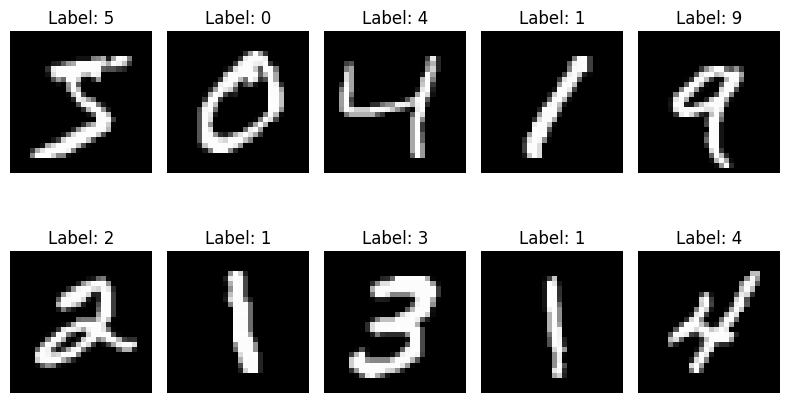

In [3]:
# Visualize sample images
plt.figure(figsize=(8, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
keras_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

keras_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

keras_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = keras_model.fit(
    x_train, y_train,
    validation_split=0.10,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8826 - loss: 0.4067 - val_accuracy: 0.9603 - val_loss: 0.1415
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9468 - loss: 0.1801 - val_accuracy: 0.9672 - val_loss: 0.1105
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9597 - loss: 0.1333 - val_accuracy: 0.9735 - val_loss: 0.0905
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9670 - loss: 0.1066 - val_accuracy: 0.9755 - val_loss: 0.0793
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9713 - loss: 0.0928 - val_accuracy: 0.9777 - val_loss: 0.0763


In [6]:
# Evaluate
keras_loss, keras_accuracy = keras_model.evaluate(x_test, y_test, verbose=0)

print(f"TensorFlow/Keras Test Loss: {keras_loss:.4f}")
print(f"TensorFlow/Keras Test Accuracy: {keras_accuracy:.4f}")
print(f"TensorFlow/Keras Test Accuracy: {keras_accuracy*100:.2f}%")

TensorFlow/Keras Test Loss: 0.0875
TensorFlow/Keras Test Accuracy: 0.9730
TensorFlow/Keras Test Accuracy: 97.30%


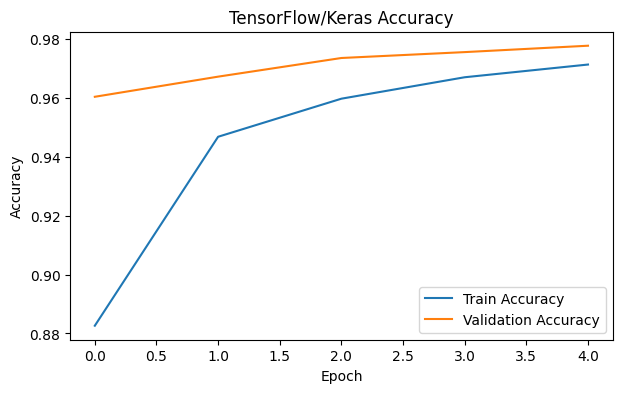

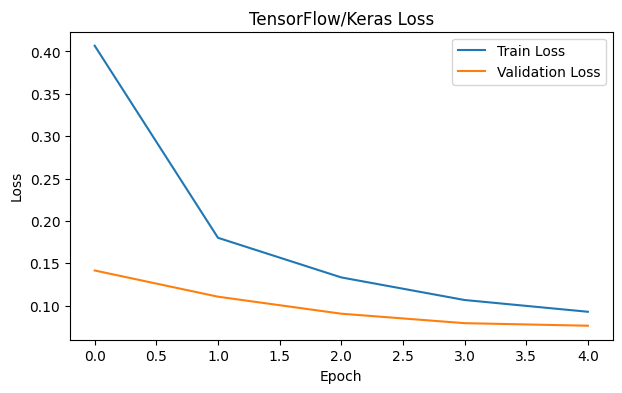

In [7]:
# Plot training history
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("TensorFlow/Keras Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("TensorFlow/Keras Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [8]:
PYTORCH_TEST_ACCURACY = 0.9878

comparison = pd.DataFrame({
    "Framework": ["PyTorch (Week 2)", "TensorFlow/Keras (Week 3)"],
    "Test Accuracy": [PYTORCH_TEST_ACCURACY, keras_accuracy]
})

display(comparison)

print("Comparison note:")
print("Both frameworks can build effective neural networks. The main difference is the API and workflow; Keras provides a high-level model-building interface.")

,Framework,Test Accuracy
0,PyTorch (Week 2),0.9878
1,TensorFlow/Keras (Week 3),0.9730


Comparison note:
Both frameworks can build effective neural networks. The main difference is the API and workflow; Keras provides a high-level model-building interface.


In [9]:
# Save TensorFlow model
keras_model.save("week3_tensorflow_mnist_model.keras")
print("Saved: week3_tensorflow_mnist_model.keras")

Saved: week3_tensorflow_mnist_model.keras


# 3.2 Computer Vision Classification Project

A real computer-vision classification task is implemented using the CIFAR-10 dataset. The dataset contains 10 image classes. A CNN is trained using TensorFlow/Keras and evaluated with accuracy, a classification report, and a confusion matrix.

In [10]:
(xc_train, yc_train), (xc_test, yc_test) = keras.datasets.cifar10.load_data()

xc_train = xc_train.astype("float32") / 255.0
xc_test = xc_test.astype("float32") / 255.0

yc_train = yc_train.flatten()
yc_test = yc_test.flatten()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training:", xc_train.shape)
print("Testing:", xc_test.shape)

Training: (50000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


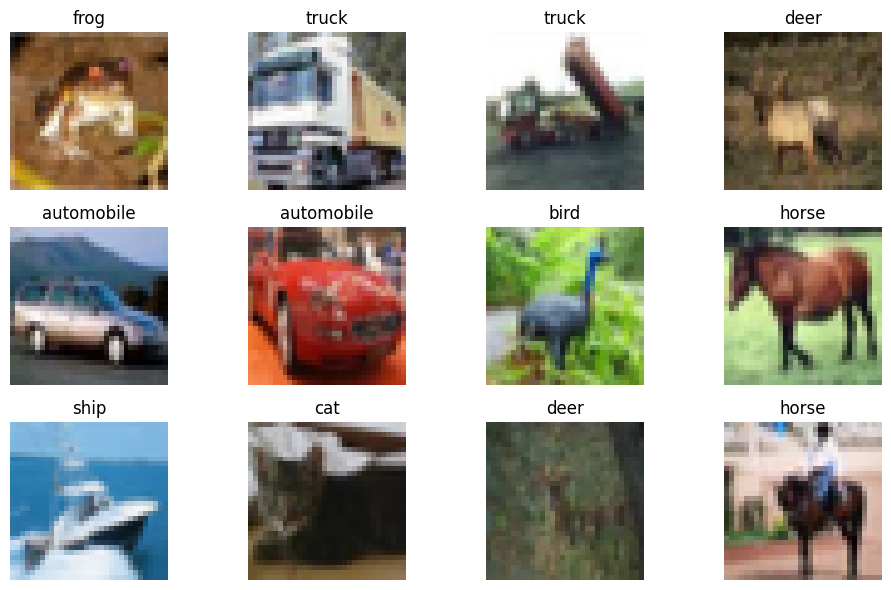

In [11]:
# Show CIFAR-10 samples
plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(xc_train[i])
    plt.title(class_names[yc_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(10, activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train CNN
cnn_history = cnn.fit(
    xc_train, yc_train,
    validation_split=0.10,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.3938 - loss: 1.6574 - val_accuracy: 0.5282 - val_loss: 1.3053
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5498 - loss: 1.2662 - val_accuracy: 0.6120 - val_loss: 1.1024
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6162 - loss: 1.0803 - val_accuracy: 0.6512 - val_loss: 0.9972
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6600 - loss: 0.9677 - val_accuracy: 0.6844 - val_loss: 0.9151
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6889 - loss: 0.8830 - val_accuracy: 0.7080 - val_loss: 0.8462


In [14]:
# Evaluate CNN
cnn_loss, cnn_accuracy = cnn.evaluate(xc_test, yc_test, verbose=0)

print(f"CNN Test Loss: {cnn_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")
print(f"CNN Test Accuracy: {cnn_accuracy*100:.2f}%")

CNN Test Loss: 0.8773
CNN Test Accuracy: 0.6928
CNN Test Accuracy: 69.28%


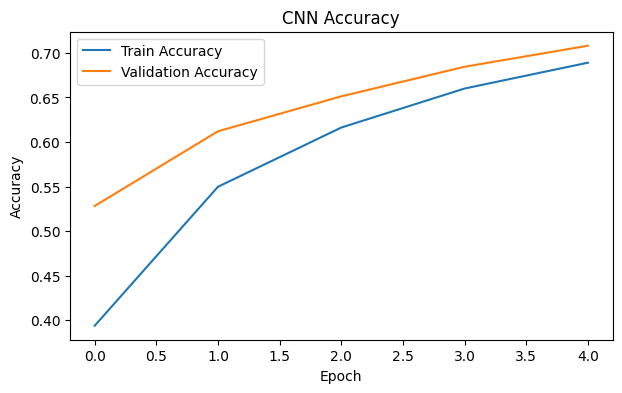

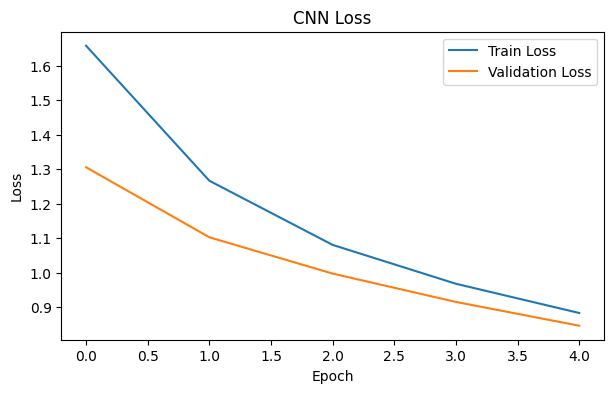

In [15]:
# CNN learning curves
cnn_history_df = pd.DataFrame(cnn_history.history)

plt.figure(figsize=(7, 4))
plt.plot(cnn_history_df["accuracy"], label="Train Accuracy")
plt.plot(cnn_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cnn_history_df["loss"], label="Train Loss")
plt.plot(cnn_history_df["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

              precision    recall  f1-score   support

    airplane       0.75      0.72      0.74      1000
  automobile       0.81      0.83      0.82      1000
        bird       0.65      0.54      0.59      1000
         cat       0.46      0.55      0.50      1000
        deer       0.64      0.64      0.64      1000
         dog       0.57      0.63      0.60      1000
        frog       0.85      0.65      0.74      1000
       horse       0.75      0.76      0.76      1000
        ship       0.73      0.87      0.80      1000
       truck       0.79      0.74      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



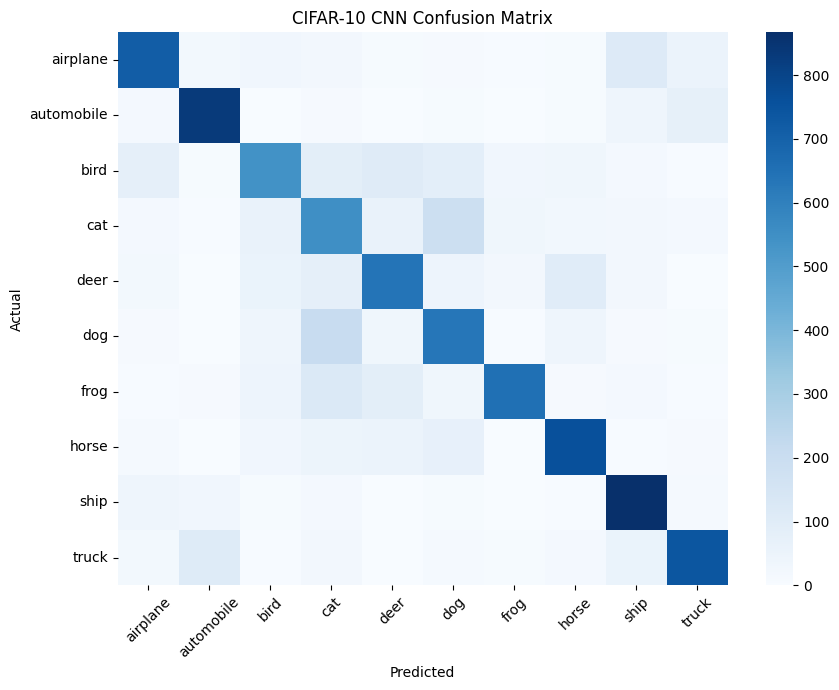

In [16]:
# Classification report and confusion matrix
pred_probs = cnn.predict(xc_test, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

print(classification_report(yc_test, pred_labels, target_names=class_names))

cm = confusion_matrix(yc_test, pred_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("CIFAR-10 CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

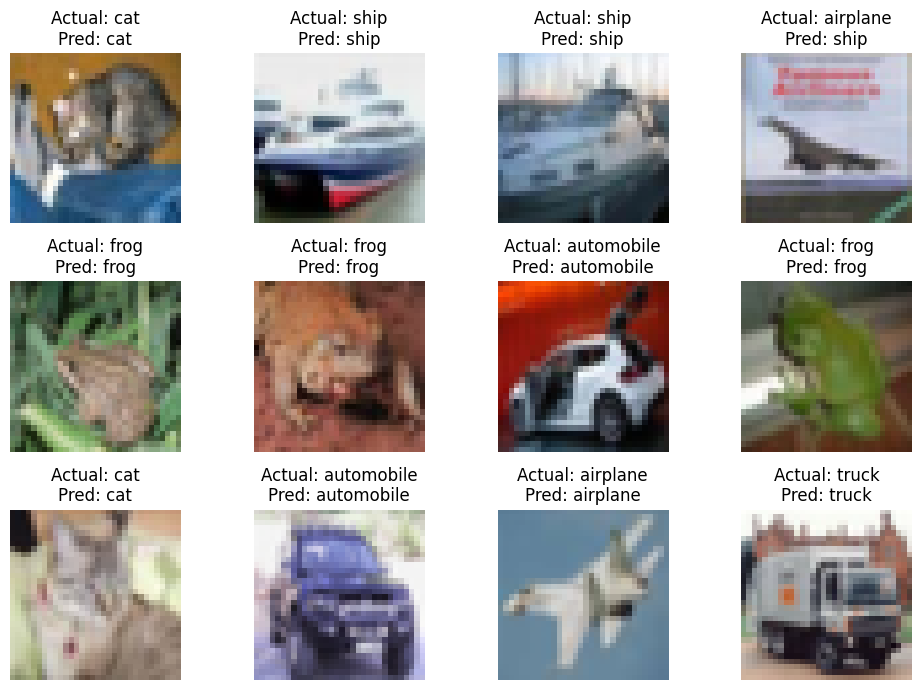

In [17]:
# Sample predictions
plt.figure(figsize=(10, 7))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(xc_test[i])
    actual = class_names[yc_test[i]]
    predicted = class_names[pred_labels[i]]
    plt.title(f"Actual: {actual}\nPred: {predicted}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
# Save CNN and result summary
cnn.save("week3_cifar10_cnn.keras")

results = pd.DataFrame({
    "Model": ["TensorFlow/Keras Dense Network", "TensorFlow/Keras CNN"],
    "Dataset": ["MNIST", "CIFAR-10"],
    "Test Accuracy": [keras_accuracy, cnn_accuracy]
})

display(results)
results.to_csv("week3_model_results.csv", index=False)
print("Saved: week3_cifar10_cnn.keras")
print("Saved: week3_model_results.csv")

,Model,Dataset,Test Accuracy
0,TensorFlow/Keras Dense Network,MNIST,0.9730
1,TensorFlow/Keras CNN,CIFAR-10,0.6928


Saved: week3_cifar10_cnn.keras
Saved: week3_model_results.csv


# 3.3 Prompt Engineering Portfolio

The goal is to design prompts for four practical use cases: reasoning, extraction, summarization, and coding. Each task is tested through multiple prompt versions.

Because this notebook is designed to run without paid APIs, the evaluation sheet records the prompt, intended output, quality criteria, and final assessment. The prompts can also be copied into any LLM for live testing.

In [19]:
prompt_rows = [
    {
        "Task": "Reasoning",
        "Version": "V1",
        "Prompt": "Solve this problem and explain your answer.",
        "Improvement": "Add constraints, request step-by-step reasoning, and ask for a final concise answer.",
        "Expected Outcome": "Correct solution with clear explanation.",
        "Evaluation Criteria": "Accuracy, clarity, logical consistency"
    },
    {
        "Task": "Reasoning",
        "Version": "V2",
        "Prompt": "Solve the following problem. State assumptions, show the key steps used to reach the answer, check the result, then give the final answer in one sentence: [PROBLEM]",
        "Improvement": "Structured reasoning and result verification.",
        "Expected Outcome": "More reliable and easier-to-check response.",
        "Evaluation Criteria": "Accuracy, verification, clarity"
    },
    {
        "Task": "Extraction",
        "Version": "V1",
        "Prompt": "Extract the important information from this text: [TEXT]",
        "Improvement": "Specify an exact JSON schema.",
        "Expected Outcome": "Consistent structured information.",
        "Evaluation Criteria": "Completeness, structure, no invented fields"
    },
    {
        "Task": "Extraction",
        "Version": "V2",
        "Prompt": "Extract only the following fields from the text and return valid JSON: name, organization, date, amount. Use null when a field is missing. Text: [TEXT]",
        "Improvement": "Fixed fields and missing-value rule.",
        "Expected Outcome": "Machine-readable JSON with controlled output.",
        "Evaluation Criteria": "Correct fields, valid JSON, no extra text"
    },
    {
        "Task": "Summarization",
        "Version": "V1",
        "Prompt": "Summarize this article: [TEXT]",
        "Improvement": "Set length, audience, and required points.",
        "Expected Outcome": "Focused summary.",
        "Evaluation Criteria": "Coverage, conciseness, factual consistency"
    },
    {
        "Task": "Summarization",
        "Version": "V2",
        "Prompt": "Summarize the text in 5 bullet points for a university student. Include the main idea, 3 important findings, and the final conclusion. Do not add information not present in the text: [TEXT]",
        "Improvement": "Defined format, audience, and hallucination control.",
        "Expected Outcome": "Short, focused and faithful summary.",
        "Evaluation Criteria": "Relevance, factuality, readability"
    },
    {
        "Task": "Coding",
        "Version": "V1",
        "Prompt": "Write Python code for this task: [TASK]",
        "Improvement": "Specify inputs, outputs, edge cases, libraries, and testing.",
        "Expected Outcome": "Runnable and testable code.",
        "Evaluation Criteria": "Correctness, readability, edge cases"
    },
    {
        "Task": "Coding",
        "Version": "V2",
        "Prompt": "Write clean Python 3 code for [TASK]. Use only standard libraries unless needed. Define inputs and outputs, handle invalid input, include comments for important logic, and provide 2 small test cases. Do not use hard-coded results.",
        "Improvement": "Adds requirements and tests.",
        "Expected Outcome": "More robust and reusable code.",
        "Evaluation Criteria": "Correctness, tests, readability, robustness"
    }
]

prompt_df = pd.DataFrame(prompt_rows)
display(prompt_df)
prompt_df.to_csv("week3_prompt_evaluation.csv", index=False)
print("Saved: week3_prompt_evaluation.csv")

,Task,Version,Prompt,Improvement,Expected Outcome,Evaluation Criteria
0,Reasoning,V1,Solve this problem and explain your answer.,"Add constraints, request step-by-step reasonin...",Correct solution with clear explanation.,"Accuracy, clarity, logical consistency"
1,Reasoning,V2,Solve the following problem. State assumptions...,Structured reasoning and result verification.,More reliable and easier-to-check response.,"Accuracy, verification, clarity"
2,Extraction,V1,Extract the important information from this te...,Specify an exact JSON schema.,Consistent structured information.,"Completeness, structure, no invented fields"
3,Extraction,V2,Extract only the following fields from the tex...,Fixed fields and missing-value rule.,Machine-readable JSON with controlled output.,"Correct fields, valid JSON, no extra text"
4,Summarization,V1,Summarize this article: [TEXT],"Set length, audience, and required points.",Focused summary.,"Coverage, conciseness, factual consistency"
5,Summarization,V2,Summarize the text in 5 bullet points for a un...,"Defined format, audience, and hallucination co...","Short, focused and faithful summary.","Relevance, factuality, readability"
6,Coding,V1,Write Python code for this task: [TASK],"Specify inputs, outputs, edge cases, libraries...",Runnable and testable code.,"Correctness, readability, edge cases"
7,Coding,V2,Write clean Python 3 code for [TASK]. Use only...,Adds requirements and tests.,More robust and reusable code.,"Correctness, tests, readability, robustness"


Saved: week3_prompt_evaluation.csv


In [20]:
# Prompt engineering conclusion
summary = pd.DataFrame({
    "Area": ["Reasoning", "Extraction", "Summarization", "Coding"],
    "Best practice identified": [
        "Give structure and ask for result verification.",
        "Define exact fields and a strict output format.",
        "Specify audience, length, required points, and factuality.",
        "Define inputs/outputs, edge cases, libraries, and tests."
    ]
})
display(summary)

,Area,Best practice identified
0,Reasoning,Give structure and ask for result verification.
1,Extraction,Define exact fields and a strict output format.
2,Summarization,"Specify audience, length, required points, and..."
3,Coding,"Define inputs/outputs, edge cases, libraries, ..."


# 3.4 AI-Assisted Coding Task

A small prediction application is created with Gradio. The application uses the trained CIFAR-10 CNN to classify an uploaded image.

AI-assisted coding audit:
- Generated code should be reviewed rather than accepted blindly.
- Input validation and clear error handling are checked.
- Model loading is separated from prediction logic.
- The interface is kept simple so the workflow is easy to understand and demonstrate.

In [21]:
import gradio as gr

# Reuse the trained CNN already in memory.
def predict_image(image):
    if image is None:
        return {"No image": 1.0}

    image_array = np.array(image).astype("float32") / 255.0
    image_array = tf.image.resize(image_array, (32, 32))
    image_array = tf.expand_dims(image_array, axis=0)

    probabilities = cnn.predict(image_array, verbose=0)[0]

    return {
        class_names[i]: float(probabilities[i])
        for i in range(len(class_names))
    }

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy", label="Upload a CIFAR-10 style image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="CIFAR-10 Image Classifier",
    description="Upload an image and the trained TensorFlow CNN will return its top predictions."
)

print("Gradio application created successfully.")
print("Run the next cell to launch it.")

Gradio application created successfully.
Run the next cell to launch it.


In [22]:
# Launch the app in Colab
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://52fe5c3e509466e689.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 3.4 Short Code Audit

1. Correctness: The input image is normalized and resized to the same 32×32 format used by the CNN.
2. Validation: The app handles an empty input instead of attempting prediction.
3. Maintainability: Prediction logic is kept in one function and class names are stored in a single list.
4. Security: No API keys, passwords, or private credentials are used.
5. Testing: The notebook should be tested with a valid image and with no image.
6. Improvement: In a production application, the model would be loaded from a versioned model file rather than relying on the current notebook session.

This demonstrates the required review-and-audit mindset for AI-assisted coding.